In [27]:
import pandas as pd

In [28]:
df =pd.read_csv('xclara.csv')

In [29]:
df.head()

,V1,V2
0,2.072345,-3.241693
1,17.936710,15.784810
2,1.083576,7.319176
3,11.120670,14.406780
4,23.711550,2.557729


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      3000 non-null   float64
 1   V2      3000 non-null   float64
dtypes: float64(2)
memory usage: 47.0 KB


In [31]:
df.describe()

,V1,V2
count,3000.000000,3000.000000
mean,40.611358,22.862141
std,25.859054,31.759714
min,-22.495990,-38.795500
25%,18.462790,-4.003494
50%,41.552210,13.827390
75%,62.249480,55.729100
max,104.376600,87.313700


In [32]:
df.shape

(3000, 2)

In [33]:
df.isnull().sum().sort_values(ascending=False)

V1    0
V2    0
dtype: int64

In [34]:
df['V1'].value_counts

<bound method IndexOpsMixin.value_counts of 0        2.072345
1       17.936710
2        1.083576
3       11.120670
4       23.711550
          ...    
2995    85.652800
2996    82.770880
2997    64.465320
2998    90.722820
2999    64.879760
Name: V1, Length: 3000, dtype: float64>

In [35]:
df['V2'].value_counts

<bound method IndexOpsMixin.value_counts of 0       -3.241693
1       15.784810
2        7.319176
3       14.406780
4        2.557729
          ...    
2995    -6.461061
2996    -2.373299
2997   -10.501360
2998   -12.255840
2999   -24.877310
Name: V2, Length: 3000, dtype: float64>

In [38]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
for col in df.columns:
 df[col]=scale.fit_transform(df[[col]])

In [39]:
df

,V1,V2
0,-1.490597,-0.822054
1,-0.877001,-0.222877
2,-1.528841,-0.489474
3,-1.140630,-0.266274
4,-0.653644,-0.639420
...,...,...
2995,1.742096,-0.923437
2996,1.630630,-0.794706
2997,0.922614,-1.050673
2998,1.938192,-1.105924


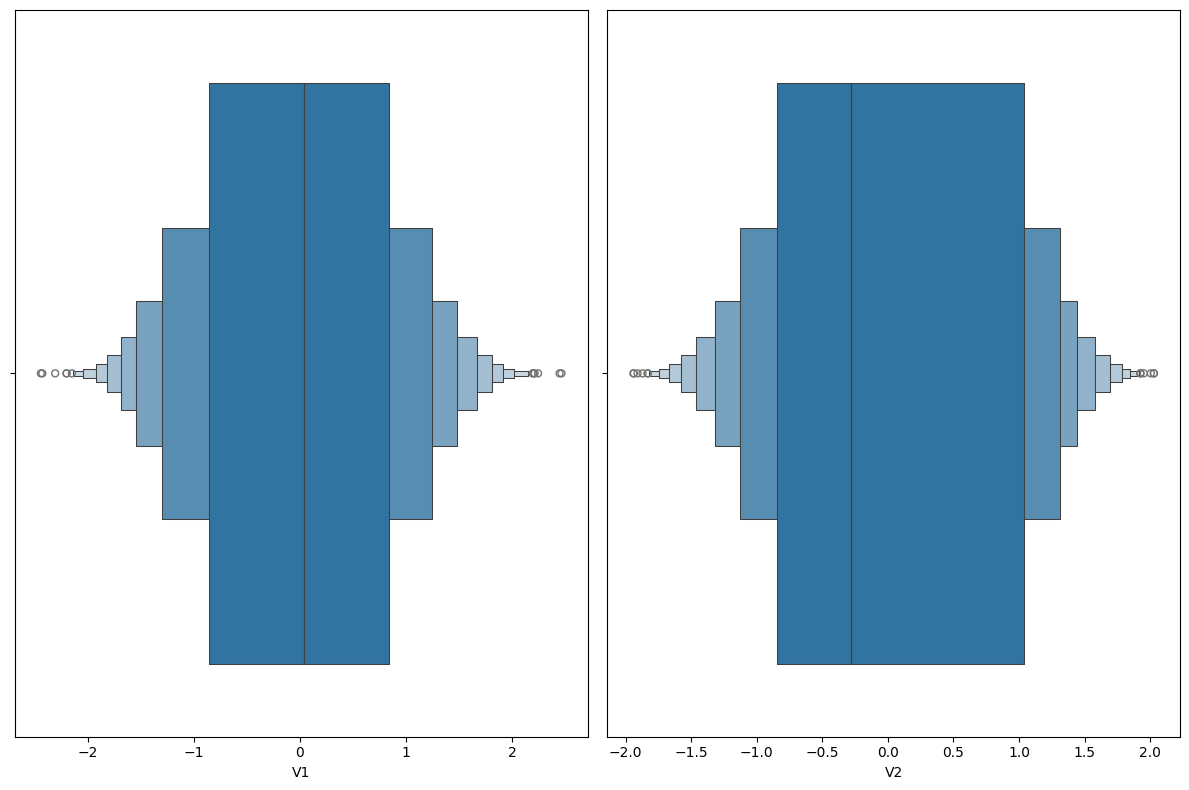

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,8))
for i,col in enumerate(df.columns,1):
   plt.subplot(1,2,i)
   sns.boxenplot(x=df[col])

plt.tight_layout()
plt.show()

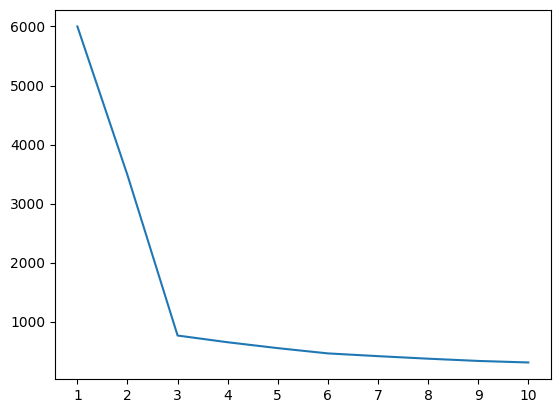

In [41]:
from sklearn.cluster import KMeans
# elbow method
scores=[]
for k in range(1,11):
  mod=KMeans(n_clusters=k,random_state=42)
  mod.fit(df[['V1','V2']])
  scores.append(mod.inertia_)
plt.xticks(range(1,11))
plt.plot(range(1,11),scores)  
plt.show()

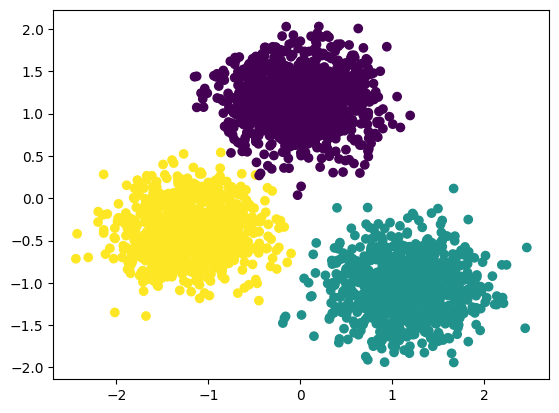

In [42]:
# 3 is the best k 
km = KMeans(n_clusters=3,random_state=42)
km.fit(df[['V1','V2']])
# plt.scatter(df['V1'],df['V2'],c=km.labels_)
# or
y_pred=km.predict(df[['V1','V2']])
plt.scatter(df['V1'],df['V2'],c=y_pred) 
